In [1]:
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import scipy.stats as stats
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt 
import matplotlib as mpl
import os
import skimage
import copy

from watermark import watermark
print(watermark())
print(watermark(packages="pandas,numpy,matplotlib,scipy,seaborn"))

Last updated: 2026-03-30T11:07:20.024863-07:00

Python implementation: CPython
Python version       : 3.13.9
IPython version      : 9.6.0

Compiler    : MSC v.1944 64 bit (AMD64)
OS          : Windows
Release     : 10
Machine     : AMD64
Processor   : Intel64 Family 6 Model 63 Stepping 2, GenuineIntel
CPU cores   : 72
Architecture: 64bit

pandas    : 2.2.3
numpy     : 2.1.2
matplotlib: 3.10.7
scipy     : 1.14.1
seaborn   : 0.13.2



In [2]:
ss_files = [f for f in os.listdir('decoded_sum_stats')] # if 'decode_summary_stats_pos_' in f and int(f.split('pos_')[1].split('.')[0]) < 9]

In [3]:
ss_files

['decode_summary_stats_pos_0.csv',
 'decode_summary_stats_pos_1.csv',
 'decode_summary_stats_pos_2.csv',
 'decode_summary_stats_pos_3.csv',
 'decode_summary_stats_pos_4.csv',
 'decode_summary_stats_pos_5.csv',
 'decode_summary_stats_pos_6.csv',
 'decode_summary_stats_pos_7.csv',
 'decode_summary_stats_pos_8.csv']

In [4]:
ss = pd.concat([pd.read_csv('decoded_sum_stats/' + f) for f in ss_files])

In [5]:
#ss = pd.read_csv('brain_rs_workflow/results/decode_summary_stats_pos_0.csv')

In [6]:
ss.drop("ch", axis=1, inplace=True)

In [7]:
ss.dropna(inplace=True)

In [8]:
np.unique(ss.pos)

array([0., 1., 2., 3., 4., 5., 6., 7., 8.])

In [9]:
ss

,Unnamed: 0.2,Unnamed: 0.1,Unnamed: 0,pos,cell,lvf,zvf,lwvf,svf,dr,n_barcodes,negative_control_barcodes,gene_encoding_barcodes,est_fp_rate,est_fdr,z
0,0,0,0,0.0,5.0,2.0,1.0,0.0,0.0,0.0,4.0,0,4.0,0.0,0.000000,0
1,1,0,0,0.0,8.0,2.0,1.0,0.0,0.0,0.0,17.0,0,17.0,0.0,0.000000,0
2,2,0,0,0.0,9.0,2.0,1.0,0.0,0.0,0.0,96.0,1,96.0,0.0,0.001543,0
3,3,0,0,0.0,10.0,2.0,1.0,0.0,0.0,0.0,37.0,0,37.0,0.0,0.000000,0
4,4,0,0,0.0,11.0,2.0,1.0,0.0,0.0,0.0,19.0,0,19.0,0.0,0.000000,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4180,15,0,0,8.0,49.0,7.0,1.0,2.0,0.0,0.0,65.0,1,65.0,0.0,0.002280,7
4181,16,0,0,8.0,50.0,7.0,1.0,2.0,0.0,0.0,3.0,0,3.0,0.0,0.000000,7
4182,17,0,0,8.0,51.0,7.0,1.0,2.0,0.0,0.0,11.0,1,11.0,0.0,0.013470,7
4183,18,0,0,8.0,57.0,7.0,1.0,2.0,0.0,0.0,3.0,0,3.0,0.0,0.000000,7


In [10]:
dcd_pams_summed = ss.groupby(['pos', 'cell', 'lvf', 'lwvf', 'dr']).sum()

In [11]:
dcd_pams_summed

Unnamed: 0.2  Unnamed: 0.1  Unnamed: 0  zvf  svf  \
pos cell lvf lwvf dr                                                      
0.0 5.0  2.0 0.0  0.0             0             0           0  6.0  0.0   
             2.0  0.0             0             0           0  6.0  0.0   
         3.0 0.0  0.0             0             0           0  6.0  0.0   
             2.0  0.0             0             0           0  6.0  0.0   
         4.0 0.0  0.0             0             0           0  6.0  0.0   
...                             ...           ...         ...  ...  ...   
8.0 61.0 5.0 2.0  0.0           142             0           0  3.0  0.0   
         6.0 0.0  0.0           142             0           0  3.0  0.0   
             2.0  0.0           142             0           0  3.0  0.0   
         7.0 0.0  0.0           142             0           0  3.0  0.0   
             2.0  0.0           142             0           0  3.0  0.0   

                       n_barcodes  negative_control_barcodes  \
pos cell lvf lwvf dr                                           
0.0 5.0  2.0 0.0  0.0       834.0                        308   
             2.0  0.0       732.0                        217   
         3.0 0.0  0.0       734.0                        204   
             2.0  0.0       635.0                        148   
         4.0 0.0  0.0       663.0                        152   
...                           ...                        ...   
8.0 61.0 5.0 2.0  0.0      1102.0                        158   
         6.0 0.0  0.0      1316.0                        330   
             2.0  0.0       963.0                        112   
         7.0 0.0  0.0      1183.0                        244   
             2.0  0.0       853.0                         73   

                       gene_encoding_barcodes  est_fp_rate   est_fdr   z  
pos cell lvf lwvf dr                                                      
0.0 5.0  2.0 0.0  0.0                   834.0          0.0  0.290527  15  
             2.0  0.0                   732.0          0.0  0.249620  15  
         3.0 0.0  0.0                   734.0          0.0  0.227822  15  
             2.0  0.0                   635.0          0.0  0.203893  15  
         4.0 0.0  0.0                   663.0          0.0  0.191206  15  
...                                       ...          ...       ...  ..  
8.0 61.0 5.0 2.0  0.0                  1102.0          0.0  0.060640  12  
         6.0 0.0  0.0                  1316.0          0.0  0.103596  12  
             2.0  0.0                   963.0          0.0  0.052547  12  
         7.0 0.0  0.0                  1183.0          0.0  0.087341  12  
             2.0  0.0                   853.0          0.0  0.040638  12  

[14649 rows x 11 columns]

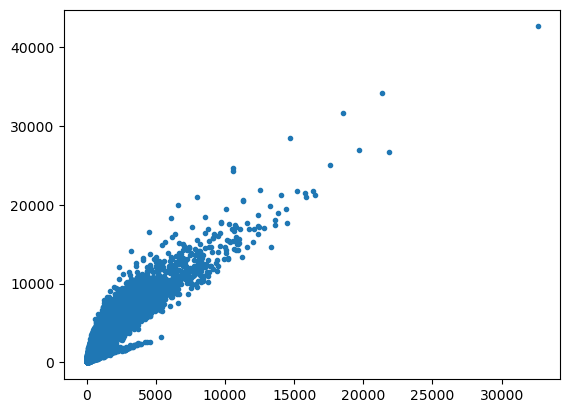

In [12]:
plt.plot(dcd_pams_summed.negative_control_barcodes, dcd_pams_summed.gene_encoding_barcodes, '.')

In [13]:
param_cell_avg = dcd_pams_summed.groupby(['lvf', 'lwvf', 'dr']).mean()

In [14]:
param_cell_avg['eFDR'] = param_cell_avg['negative_control_barcodes'] *(271/(2100-271))/param_cell_avg['gene_encoding_barcodes']

In [15]:
param_cell_avg.reset_index(inplace=True)
param_cell_avg.loc[:, "Position\nvariance\npenalty"] = np.int64(param_cell_avg["lvf"])
param_cell_avg.loc[:, "Log brightness\nvariance\npenalty"] = param_cell_avg["lwvf"]

In [16]:
param_cell_avg

,lvf,lwvf,dr,Unnamed: 0.2,Unnamed: 0.1,Unnamed: 0,zvf,svf,n_barcodes,negative_control_barcodes,gene_encoding_barcodes,est_fp_rate,est_fdr,z,eFDR,Position\nvariance\npenalty,Log brightness\nvariance\npenalty
0,2.0,0.0,0.0,319.932134,0.0,0.0,5.739984,0.0,3950.779231,2618.634505,3950.779231,0.0,0.542757,20.107114,0.098208,2,0.0
1,2.0,2.0,0.0,319.264321,0.0,0.0,5.734861,0.0,3091.524550,1528.005728,3091.524550,0.0,0.412581,20.087561,0.073233,2,2.0
2,3.0,0.0,0.0,319.168438,0.0,0.0,5.730989,0.0,3254.637776,1641.031889,3254.637776,0.0,0.406980,20.080131,0.074708,3,0.0
3,3.0,2.0,0.0,317.281506,0.0,0.0,5.714403,0.0,2470.720131,861.204583,2470.720131,0.0,0.290708,20.031097,0.051646,3,2.0
4,4.0,0.0,0.0,317.986907,0.0,0.0,5.720131,0.0,2776.267594,1104.889525,2776.267594,0.0,0.320845,20.045008,0.058968,4,0.0
5,4.0,2.0,0.0,316.114754,0.0,0.0,5.702459,0.0,2062.770492,548.968852,2062.770492,0.0,0.224403,20.016393,0.039432,4,2.0
6,5.0,0.0,0.0,316.992629,0.0,0.0,5.710893,0.0,2419.271089,794.103194,2419.271089,0.0,0.266563,20.030303,0.048635,5,0.0
7,5.0,2.0,0.0,314.495902,0.0,0.0,5.687705,0.0,1759.995902,379.183607,1759.995902,0.0,0.184699,19.961475,0.031922,5,2.0
8,6.0,0.0,0.0,315.945127,0.0,0.0,5.696970,0.0,2133.867322,597.325962,2133.867322,0.0,0.228140,19.987715,0.041476,6,0.0
9,6.0,2.0,0.0,313.440066,0.0,0.0,5.677340,0.0,1527.794745,279.145320,1527.794745,0.0,0.160695,19.935961,0.027072,6,2.0


Text(0.5, 28.999999999999986, 'Estimated FDR')

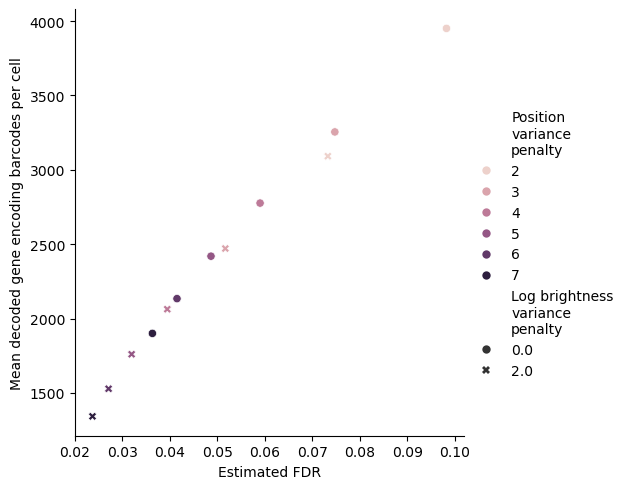

In [17]:
sns.relplot(data=param_cell_avg, x = "eFDR", y="gene_encoding_barcodes", hue="Position\nvariance\npenalty", style="Log brightness\nvariance\npenalty")
plt.ylabel("Mean decoded gene encoding barcodes per cell")
plt.xlabel("Estimated FDR")
#plt.savefig('fig2C.pdf')

Text(0.5, 28.999999999999986, 'Estimated FDR')

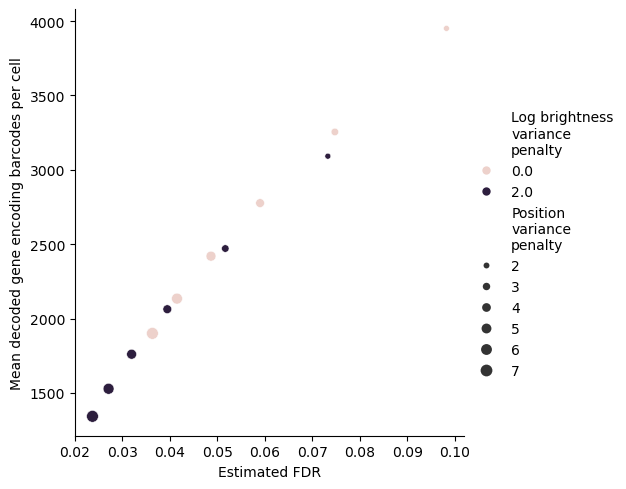

In [18]:
sns.relplot(data=param_cell_avg, x = "eFDR", y="gene_encoding_barcodes", size="Position\nvariance\npenalty", hue="Log brightness\nvariance\npenalty")
plt.ylabel("Mean decoded gene encoding barcodes per cell")
plt.xlabel("Estimated FDR")

In [19]:
param_cell_avg

,lvf,lwvf,dr,Unnamed: 0.2,Unnamed: 0.1,Unnamed: 0,zvf,svf,n_barcodes,negative_control_barcodes,gene_encoding_barcodes,est_fp_rate,est_fdr,z,eFDR,Position\nvariance\npenalty,Log brightness\nvariance\npenalty
0,2.0,0.0,0.0,319.932134,0.0,0.0,5.739984,0.0,3950.779231,2618.634505,3950.779231,0.0,0.542757,20.107114,0.098208,2,0.0
1,2.0,2.0,0.0,319.264321,0.0,0.0,5.734861,0.0,3091.524550,1528.005728,3091.524550,0.0,0.412581,20.087561,0.073233,2,2.0
2,3.0,0.0,0.0,319.168438,0.0,0.0,5.730989,0.0,3254.637776,1641.031889,3254.637776,0.0,0.406980,20.080131,0.074708,3,0.0
3,3.0,2.0,0.0,317.281506,0.0,0.0,5.714403,0.0,2470.720131,861.204583,2470.720131,0.0,0.290708,20.031097,0.051646,3,2.0
4,4.0,0.0,0.0,317.986907,0.0,0.0,5.720131,0.0,2776.267594,1104.889525,2776.267594,0.0,0.320845,20.045008,0.058968,4,0.0
5,4.0,2.0,0.0,316.114754,0.0,0.0,5.702459,0.0,2062.770492,548.968852,2062.770492,0.0,0.224403,20.016393,0.039432,4,2.0
6,5.0,0.0,0.0,316.992629,0.0,0.0,5.710893,0.0,2419.271089,794.103194,2419.271089,0.0,0.266563,20.030303,0.048635,5,0.0
7,5.0,2.0,0.0,314.495902,0.0,0.0,5.687705,0.0,1759.995902,379.183607,1759.995902,0.0,0.184699,19.961475,0.031922,5,2.0
8,6.0,0.0,0.0,315.945127,0.0,0.0,5.696970,0.0,2133.867322,597.325962,2133.867322,0.0,0.228140,19.987715,0.041476,6,0.0
9,6.0,2.0,0.0,313.440066,0.0,0.0,5.677340,0.0,1527.794745,279.145320,1527.794745,0.0,0.160695,19.935961,0.027072,6,2.0


In [20]:
param_cell_avg.reset_index()["lwvf"]

0     0.0
1     2.0
2     0.0
3     2.0
4     0.0
5     2.0
6     0.0
7     2.0
8     0.0
9     2.0
10    0.0
11    2.0
Name: lwvf, dtype: float64

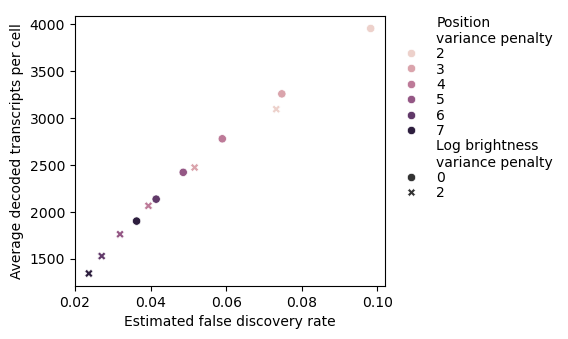

In [21]:
fig, ax = plt.subplots(figsize=(4,3.5))
#fig, axes = plt.subplots(1,1, figsize=(14,8.1), layout="constrained")

param_cell_avg.loc[:, "Position\nvariance penalty"] = np.int64(param_cell_avg.reset_index()["lvf"])
param_cell_avg.loc[:, "Log brightness\nvariance penalty"] = np.int64(param_cell_avg.reset_index()["lwvf"])
sns.scatterplot(data=param_cell_avg, x = "eFDR", y="gene_encoding_barcodes", hue='Position\nvariance penalty', style='Log brightness\nvariance penalty')
ax.set_xlabel("Estimated false discovery rate")
ax.set_ylabel("Average decoded transcripts per cell")
plt.legend(frameon=False, labelspacing=0.1, bbox_to_anchor=(1, 1.05), fontsize=10)


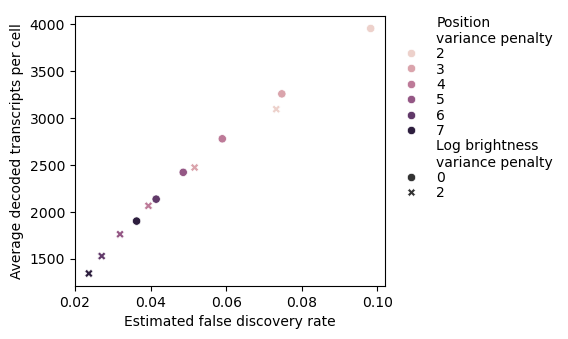

In [22]:
fig, ax = plt.subplots(figsize=(4,3.5))
#fig, axes = plt.subplots(1,1, figsize=(14,8.1), layout="constrained")

param_cell_avg.loc[:, "Position\nvariance penalty"] = np.int64(param_cell_avg.reset_index()["lvf"])
param_cell_avg.loc[:, "Log brightness\nvariance penalty"] = np.int64(param_cell_avg.reset_index()["lwvf"])
sns.scatterplot(data=param_cell_avg, x = "eFDR", y="gene_encoding_barcodes", hue='Position\nvariance penalty', style='Log brightness\nvariance penalty')
ax.set_xlabel("Estimated false discovery rate")
ax.set_ylabel("Average decoded transcripts per cell")
plt.legend(frameon=False, labelspacing=0.1, bbox_to_anchor=(1, 1.05), fontsize=10)


In [23]:
dcd_pams_summed_overz = ss.groupby(['lvf', 'lwvf', 'dr']).sum()
dcd_pams_summed_overz['eFDR'] = dcd_pams_summed_overz['negative_control_barcodes'] *(271/(2100-271))/dcd_pams_summed_overz['gene_encoding_barcodes']

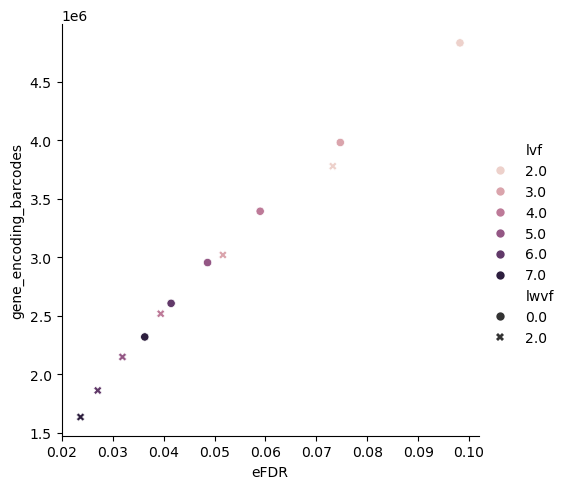

In [24]:
sns.relplot(data=dcd_pams_summed_overz, x = "eFDR", y="gene_encoding_barcodes", hue='lvf', style='lwvf')

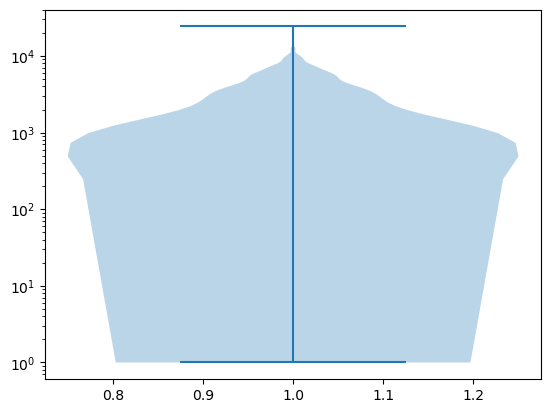

In [25]:
plt.violinplot(dcd_pams_summed.loc[:,:,5,0,0].loc[:,"gene_encoding_barcodes"])
plt.yscale("log")

In [26]:
np.where(np.sort(dcd_pams_summed.loc[:,:,5,0,0].loc[:,"gene_encoding_barcodes"] > 99))[0][0]

np.int64(103)

In [27]:
np.where(np.sort(dcd_pams_summed.loc[:,:,5,0,0].loc[:,"gene_encoding_barcodes"] > 19))[0][0]

np.int64(34)

In [28]:
np.median(dcd_pams_summed.loc[:,:,5,0,0].loc[:,"gene_encoding_barcodes"])

np.float64(1403.0)

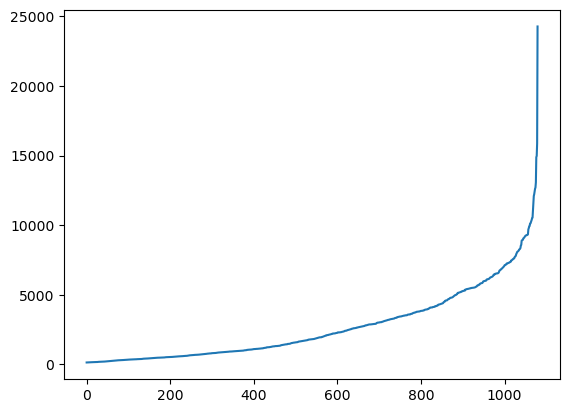

In [29]:
plt.plot(np.sort(dcd_pams_summed.loc[:,:,5,0,0].loc[:,"gene_encoding_barcodes"])[141:])

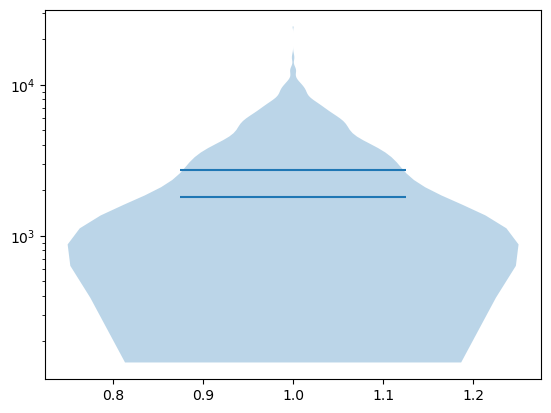

In [30]:
plt.violinplot(np.sort(dcd_pams_summed.loc[:,:,5,0,0].loc[:,"gene_encoding_barcodes"])[141:], showextrema=False, showmeans=True, showmedians=True)
plt.yscale('log')

Text(0, 0.5, '# decoded of transcripts')

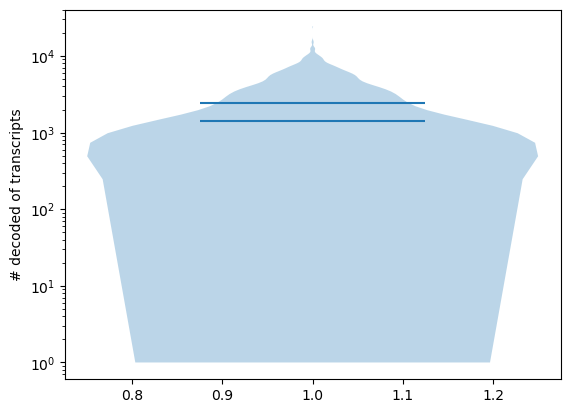

In [31]:
plt.violinplot(np.sort(dcd_pams_summed.loc[:,:,5,0,0].loc[:,"gene_encoding_barcodes"]), showextrema=False, showmeans=True, showmedians=True)
plt.yscale('log')
plt.ylabel("# decoded of transcripts")

{'bodies': [<matplotlib.collections.FillBetweenPolyCollection at 0x1eed9778910>]}

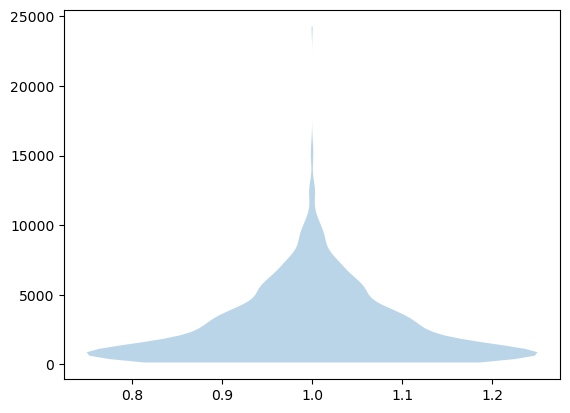

In [32]:
plt.violinplot(np.sort(dcd_pams_summed.loc[:,:,5,0,0].loc[:,"gene_encoding_barcodes"])[141:], showextrema=False)


# Get text reported statistics

In [36]:
npixels = 0
for pos in range(9):
    for z in range(8):
        lbled_img = skimage.io.imread("../../real_data_processing_workflows/mouse_cortex_rs_workflow/results/filtered_labeled_imgs/lbld_img_pos{pos}_z_{z}.png".format(pos=pos,z=z))
        regions = np.unique(lbled_img)
        cells = regions[regions != 0]
        #print(cells)
        npixels += np.sum(lbled_img != 0)

In [45]:
ss.loc[(ss.lvf ==2) & (ss.lwvf == 0), "gene_encoding_barcodes"].sum()/(npixels* (8*0.103)**2)

np.float64(5.7693362642142105)